In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import requests
from io import StringIO
from datetime import timedelta, datetime
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import FuncFormatter
import matplotlib.font_manager as fm
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / 'utils'))
from functions_visualization import *
font_path = "font-folder/Roboto-Regular.ttf"
font_path_bold = "font-folder/Roboto-Bold.ttf"
font_prop = fm.FontProperties(fname=font_path, size=20)
font_prop_legend = fm.FontProperties(fname=font_path, size=16)
font_prop_title = fm.FontProperties(fname=font_path_bold, size=22)
import matplotlib as mpl
mpl.rcParams['font.family'] = font_prop.get_name()
import warnings
warnings.filterwarnings('ignore')


/Users/stefania/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def read_csv_from_github(url):
    """
    Reads a CSV file from a given GitHub URL and returns it as a pandas DataFrame.
    input:
        url = URL of the CSV file on GitHub
    output:
        df = DataFrame containing the CSV data
    """
    response = requests.get(url)
    if response.status_code == 200:
        csv_content = response.content.decode('utf-8')
        return pd.read_csv(StringIO(csv_content))
    else:
        print(f"Failed to fetch file. Status code: {response.status_code}, Message: {response.text}")
        return pd.DataFrame()
        
def loading_surveillance_eval(start_date, github_repo, github_directory, surveillance_file, state, horizon_to_start):
    """
    This function loads the surveillance data from a GitHub repository.
    input:
        start_date = start date for the data
        github_repo = GitHub repository name
        github_directory = directory in the GitHub repository
        surveillance_file = name of the surveillance file
        state = state to filter the data
        horizon_to_start = horizon to start the data
    output:
        df_surv_date_US = dataframe with the filtered surveillance data
    """
    file_url = f"https://raw.githubusercontent.com/{github_repo}/main/{github_directory}/{surveillance_file}"
    df_surv = read_csv_from_github(file_url)
    start_date = pd.to_datetime(start_date)
    df_surv['date'] = pd.to_datetime(df_surv['date'])
    if state == 'all':
        df_surv_date_US = df_surv[(df_surv.date >= start_date)]
    else:
        df_surv_date_US = df_surv[(df_surv.location == state) & (df_surv.date >= start_date)]
    df_surv_date_US = df_surv_date_US.rename(columns={"value": "hospitalizations"})
    df_surv_date_US = df_surv_date_US.sort_values(by='date')
    df_surv_date_US['horizon'] = np.arange(1, len(df_surv_date_US)+1)
    if state == 'all':
        df_surv_date_US['horizon'] = df_surv_date_US.groupby('location').cumcount() + 1
    if 'X' in df_surv_date_US.columns:
        df_surv_date_US.drop(columns=['X'], inplace=True)
    df_surv_date_US = df_surv_date_US[df_surv_date_US['horizon'] >= horizon_to_start]
    df_surv_date_US['date'] = pd.to_datetime(df_surv_date_US['date'])
    return df_surv_date_US

In [3]:
# Loading surveillance data for evaluation: last surveillance file
github_repo = "cdcepi/FluSight-forecast-hub" # for influenza
#github_repo = "CDCgov/covid19-forecast-hub" # for covid
github_directory = "auxiliary-data/target-data-archive"
state = 'US'
start_date = datetime(2024, 11, 16)  # Adjusted to the latest date in the surveillance data
surveillance_file = "target-hospital-admissions_2025-06-14.csv"
horizon_to_start = 3
df_surv = loading_surveillance_eval(start_date, github_repo, github_directory, surveillance_file, state, horizon_to_start)
df_surv = df_surv.iloc[:-2]
df_surv['horizon'] = df_surv['horizon'] + 13
df_surv.head()

,date,location,location_name,hospitalizations,weekly_rate,horizon
3888,2024-11-30,US,US,4261.0,1.272264,16
4638,2024-12-07,US,US,6271.0,1.872416,17
3889,2024-12-14,US,US,9131.0,2.726364,18
6956,2024-12-21,US,US,15374.0,4.590420,19
5735,2024-12-28,US,US,27597.0,8.240004,20


In [4]:
loss_function = 'wmape'
season = '2024-2025'
df_wis = pd.read_csv(f"../output_data/review_performance_evaluation_bootstrap/wis_performance_{loss_function}.csv")
df_mae = pd.read_csv(f"../output_data/review_performance_evaluation_bootstrap/mae_performance_{loss_function}.csv")
df_wis

,n_bootstrap,k_perc,week,wis_adaptive_ensemble2,wis_original_ensemble2,wis_rel_original2
0,0,5,2024-11-30,7893.633821,8059.021097,0.979478
1,0,5,2024-12-07,7993.346943,8217.248436,0.972752
2,0,5,2024-12-14,9138.842961,8370.062534,1.091849
3,0,5,2024-12-21,9365.900175,8533.872453,1.097497
4,0,5,2024-12-28,9995.069179,8743.795071,1.143104
...,...,...,...,...,...,...
1295,9,75,2025-04-26,949.432447,988.884001,0.960105
1296,9,75,2025-05-03,869.650017,903.082745,0.962979
1297,9,75,2025-05-10,834.854146,865.794204,0.964264
1298,9,75,2025-05-17,814.827246,845.666261,0.963533


In [5]:
df_wis = df_wis[df_wis['week'] <= '2025-03-29']
df_mae = df_mae[df_mae['week'] <= '2025-03-29']
df_mae

,n_bootstrap,k_perc,week,mae_adaptive_ensemble2,mae_original_ensemble2,mae_rel_original2
0,0,5,2024-11-30,0.585630,0.638259,0.917542
1,0,5,2024-12-07,0.587728,0.633404,0.927888
2,0,5,2024-12-14,0.607131,0.630741,0.962567
3,0,5,2024-12-21,0.609220,0.632029,0.963912
4,0,5,2024-12-28,0.625568,0.648225,0.965048
...,...,...,...,...,...,...
1287,9,75,2025-03-01,0.714093,0.727771,0.981206
1288,9,75,2025-03-08,0.711991,0.728626,0.977169
1289,9,75,2025-03-15,0.708595,0.729452,0.971407
1290,9,75,2025-03-22,0.710171,0.731556,0.970767


Data format for plotting boxplots of different k values

In [6]:
# -------- WIS --------
df_melted_wis = df_wis.melt(id_vars=['k_perc', 'n_bootstrap'], value_vars=['wis_rel_original2'], 
                    var_name='metric', value_name='value')
df_melted_wis['k_perc'] = df_melted_wis['k_perc'].astype(str)
df_melted_wis

# MAE
df_melted_mae = df_mae.melt(id_vars=['k_perc', 'n_bootstrap'], value_vars=['mae_rel_original2'], 
                    var_name='metric', value_name='value')
df_melted_mae['k_perc'] = df_melted_mae['k_perc'].astype(str)
df_melted_mae

,k_perc,n_bootstrap,metric,value
0,5,0,mae_rel_original2,0.917542
1,5,0,mae_rel_original2,0.927888
2,5,0,mae_rel_original2,0.962567
3,5,0,mae_rel_original2,0.963912
4,5,0,mae_rel_original2,0.965048
...,...,...,...,...
895,75,9,mae_rel_original2,0.981206
896,75,9,mae_rel_original2,0.977169
897,75,9,mae_rel_original2,0.971407
898,75,9,mae_rel_original2,0.970767


Data format for plotting metrics in time (for k = 15,25,50 and separately in supplementary k=5,75)

In [7]:
df_surv.rename(columns={"date": "week"}, inplace=True)
df_wis_k_5, df_wis_k_15, df_wis_k_25, df_wis_k_50, df_wis_k_75 = get_wis_dataframes(df_wis, df_surv)
df_mae_k_5, df_mae_k_15, df_mae_k_25, df_mae_k_50, df_mae_k_75 = get_mae_dataframes(df_mae, df_surv)

Define colors palette and references

In [8]:
# Palette
palette = {
    '5': '#1d4f60',
    '15': '#2d7974',
    '25': '#4da284',
    '50': '#80c799',
    '75': '#c4e6c3'
}
color_swarm = '#103a43'
color_hosp = 'grey'
y_lim = [0.7, 1.2]

Visualization

findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not found.
findfont: Font family 'Roboto' not

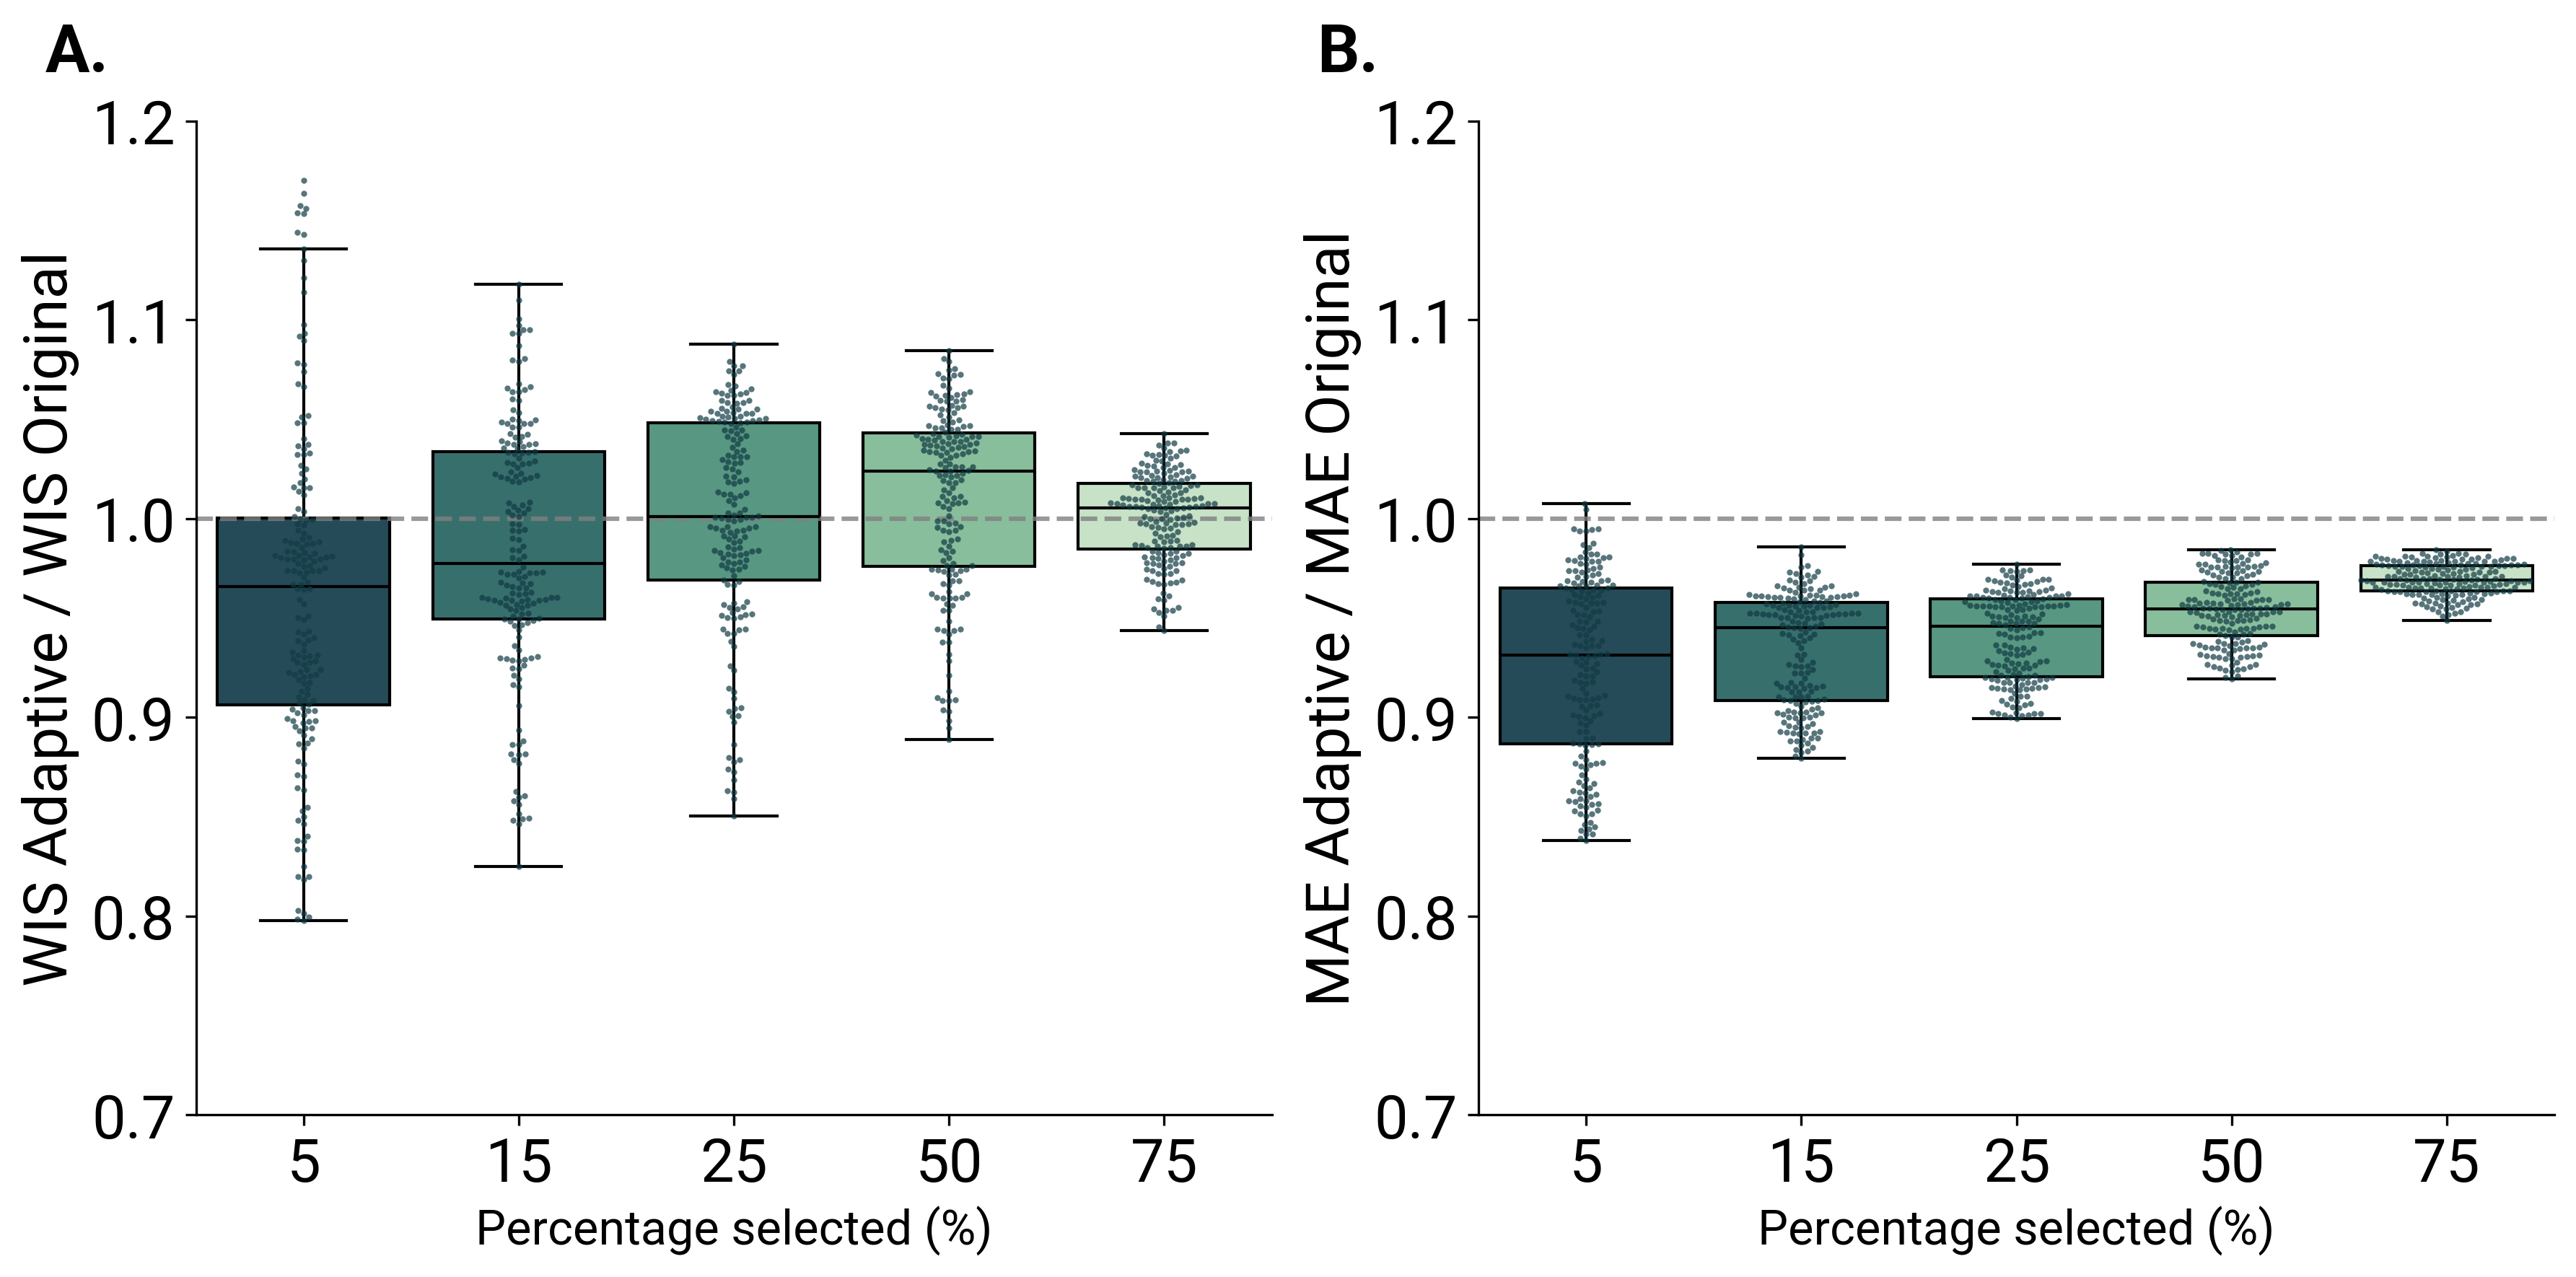

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300)

# --- FIRST SUBPLOT (A): WIS ---
ax1 = axes[0]
sns.boxplot(data=df_melted_wis, x='k_perc', y='value', ax=ax1, palette=palette, showfliers=False,
            boxprops=dict(edgecolor='black', linewidth=1.0),
            whiskerprops=dict(color='black', linewidth=1.0),
            capprops=dict(color='black', linewidth=1.0),
            medianprops=dict(color='black', linewidth=1.0))
sns.swarmplot(data=df_melted_wis, x='k_perc', y='value', ax=ax1, color=color_swarm, size=2, alpha=0.7)
#sns.scatterplot(x=means_wis.index, y=means_wis.values, ax=ax1, color=color_swarm,
#                marker='s', s=100, zorder=5)
ax1.axhline(1, color='grey', linestyle='--', alpha=0.8)
ax1.set_xlabel('Percentage selected (%)', fontproperties=font_prop_legend)
ax1.set_ylabel('WIS Adaptive / WIS Original', fontproperties=font_prop)
ax1.text(-0.14, 1.05, 'A.', transform=ax1.transAxes, fontproperties=font_prop_title)
sns.despine(ax=ax1)

# --- SECOND SUBPLOT (B): MAE ---
ax2 = axes[1]
sns.boxplot(data=df_melted_mae, x='k_perc', y='value', ax=ax2, palette=palette, showfliers=False,
            boxprops=dict(edgecolor='black', linewidth=1.0),
            whiskerprops=dict(color='black', linewidth=1.0),
            capprops=dict(color='black', linewidth=1.0),
            medianprops=dict(color='black', linewidth=1.0))
sns.swarmplot(data=df_melted_mae, x='k_perc', y='value', ax=ax2, color=color_swarm, size=2, alpha=0.7)
#sns.scatterplot(x=means_mae.index, y=means_mae.values, ax=ax2, color=color_swarm,
#                marker='s', s=100, zorder=5)

ax2.axhline(1, color='grey', linestyle='--', alpha=0.8)
ax2.set_xlabel('Percentage selected (%)', fontproperties=font_prop_legend)
ax2.set_ylabel('MAE Adaptive / MAE Original', fontproperties=font_prop)
ax2.text(-0.15, 1.05, 'B.', transform=ax2.transAxes, fontproperties=font_prop_title)
ax1.set_ylim(y_lim[0], y_lim[1])
ax2.set_ylim(y_lim[0], y_lim[1])
sns.despine(ax=ax2)

for ax in [ax1, ax2]:
    for label in ax.get_yticklabels() + ax.get_xticklabels():
        label.set_fontproperties(font_prop)
plt.tight_layout()
#plt.savefig('../figures/wis_mae_main.png', dpi=300)
plt.show()